In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [2]:
df = pd.read_csv("/content/Student Study Habits Survey.csv")

print("Dataset Shape:", df.shape)
df.head()

Dataset Shape: (43, 6)


,Timestamp,What is your full name?,"On average, how many hours per day do you spend actively studying outside of class?",How often do you use your mobile phone for non-study related activities while you are studying?,What is your overall class attendance percentage this semester?,Please rate your level of participation in doubt-clearing sessions or Q&A periods.
0,2025/12/22 10:00:48 AM GMT+5:30,Matheshwaran,03:15:00,Almost constantly,93,4.0
1,2025/12/22 10:00:57 AM GMT+5:30,Visvesh M,01:00:00,Occasionally (1-3 times per hour),90%,5.0
2,2025/12/22 10:01:04 AM GMT+5:30,David Jeff P,02:00:00,Occasionally (1-3 times per hour),92%,3.0
3,2025/12/22 10:01:11 AM GMT+5:30,Prajinchandru G,02:47:10,Rarely (Less than once per hour),80,3.0
4,2025/12/22 10:01:35 AM GMT+5:30,Sri Gayathri S,03:30:30,Frequently (More than 3 times per hour),98%,3.0


In [3]:
df.info()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 43 entries, 0 to 42
Data columns (total 6 columns):
 #   Column                                                                                           Non-Null Count  Dtype  
---  ------                                                                                           --------------  -----  
 0   Timestamp                                                                                        43 non-null     object 
 1   What is your full name?                                                                          42 non-null     object 
 2   On average, how many hours per day do you spend actively studying outside of class?              42 non-null     object 
 3   How often do you use your mobile phone for non-study related activities while you are studying?  42 non-null     object 
 4   What is your overall class attendance percentage this semester?                                  41 non-null     object 
 5   Please rate

,0
Timestamp,0
What is your full name?,1
"On average, how many hours per day do you spend actively studying outside of class?",1
How often do you use your mobile phone for non-study related activities while you are studying?,1
What is your overall class attendance percentage this semester?,2
Please rate your level of participation in doubt-clearing sessions or Q&A periods.,1


In [4]:
df_encoded = df.copy()

for col in df_encoded.columns:
    if df_encoded[col].dtype == 'object':
        df_encoded[col] = df_encoded[col].astype('category').cat.codes
df_encoded.head()

,Timestamp,What is your full name?,"On average, how many hours per day do you spend actively studying outside of class?",How often do you use your mobile phone for non-study related activities while you are studying?,What is your overall class attendance percentage this semester?,Please rate your level of participation in doubt-clearing sessions or Q&A periods.
0,0,13,10,0,12,4.0
1,1,38,2,3,10,5.0
2,2,4,5,3,11,3.0
3,3,16,6,4,5,3.0
4,4,32,12,1,17,3.0


In [11]:
df_cleaned = df_encoded.dropna()
y = df_cleaned["Please rate your level of participation in doubt-clearing sessions or Q&A periods."]
X = df_cleaned.drop(y.name, axis=1)

In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [13]:
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [14]:
y_pred = model.predict(X_test)

In [15]:
print("MAE:", mean_absolute_error(y_test, y_pred))
print("MSE:", mean_squared_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("R² Score:", r2_score(y_test, y_pred))

MAE: 0.7447168916004105
MSE: 0.8212771868876252
RMSE: 0.9062434479143147
R² Score: -0.1879187881767439


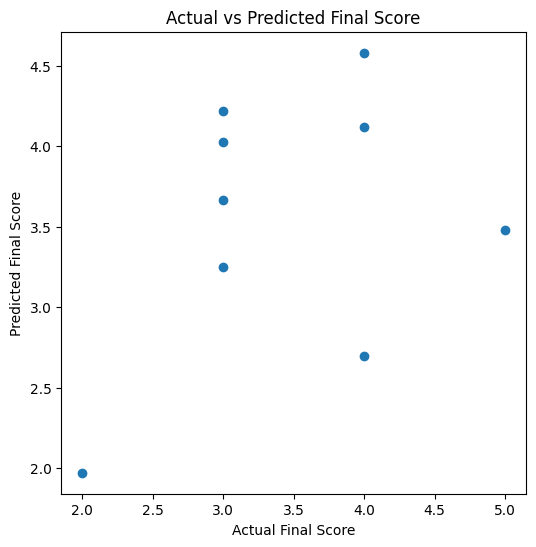

In [16]:
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Final Score")
plt.ylabel("Predicted Final Score")
plt.title("Actual vs Predicted Final Score")
plt.show()

In [17]:
new_student = np.array([[5, 7, 6, 8, 1]])
# ⚠️ Change values based on your feature count/order
predicted_score = model.predict(new_student)
print("Predicted Final Score (out of 100):", predicted_score[0])

Predicted Final Score (out of 100): 4.359754888988285


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
